In [ ]:
#python -m venv venv

#pip install tensorflow keras opencv-python numpy matplotlib scikit-learn albumentations torch torchvision torchaudio transformers
#pip install torchcam
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#pip install matplotlib numpy opencv-python pillow


## Imports

In [52]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import itertools
from torchvision.models import resnet50
from PIL import Image

In [ ]:
print(torch.cuda.is_available())  # Deve retornar True se a GPU estiver sendo usada
print(torch.cuda.get_device_name(0)) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True
NVIDIA GeForce RTX 3050


## Função de Treino

In [4]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    model.train()
    train_losses = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
    return model, train_losses

## Validação do modelo

In [ ]:
def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

## Distribuição de classes

In [6]:
def plot_class_distribution(dataset, title):
    class_counts = [len([img for img, label in dataset.samples if label == i]) for i in range(len(dataset.classes))]
    plt.figure(figsize=(8, 5))
    plt.bar(dataset.classes, class_counts, color='skyblue')
    plt.xlabel("Classes")
    plt.ylabel("Quantidade de imagens")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

## Gráfico de Perda

In [7]:
def plot_loss_curve(losses):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses)+1), losses, marker='o', linestyle='-', color='blue')
    plt.xlabel("Época")
    plt.ylabel("Perda")
    plt.title("Curva de Perda durante o Treinamento")
    plt.grid()
    plt.show()

## Matriz de Confusão

In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")
    plt.show()

## Carregar modelo pré-treinado

In [ ]:
import torch.nn as nn

class AlzheimerModel(nn.Module):
    def __init__(self):
        super(AlzheimerModel, self).__init__()
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

model = AlzheimerModel()

def load_model_if_exists(file_path):
    if os.path.exists(file_path):
        state_dict = torch.load(file_path)
        model.load_state_dict(state_dict)
        model.eval()
        return model
    else:
        return None

## Treino

c:\Users\Lucas\Desktop\Lucas\DataScience\Projeto Integrador I\AlzheimerEarlyDetection\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lucas\Desktop\Lucas\DataScience\Projeto Integrador I\AlzheimerEarlyDetection\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 0.29365732204169037
Epoch 2, Loss: 0.10207464144565165
Epoch 3, Loss: 0.061437032857460765
Epoch 4, Loss: 0.06005326353911577
Epoch 5, Loss: 0.03851793057850695
Epoch 6, Loss: 0.03831760380325639
Epoch 7, Loss: 0.03132327936144845
Epoch 8, Loss: 0.032234313403834154
Epoch 9, Loss: 0.02679881487069776
Epoch 10, Loss: 0.03185673528399743
Treinamento concluído!


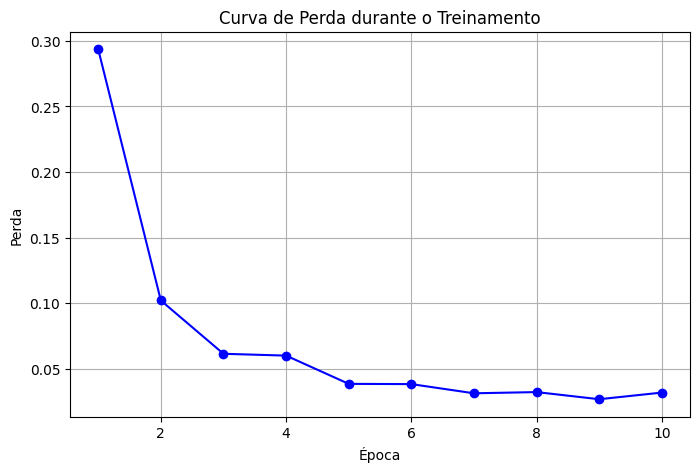

In [10]:
# Diretórios do dataset
data_dir = "datasets"
train_dir = f"{data_dir}/train"
val_dir = f"{data_dir}/val"
test_dir = f"{data_dir}/test"

# Transformações nas imagens
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ajuste para entrada do modelo
    transforms.RandomHorizontalFlip(),  # Data Augmentation
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalização
])

# Carregar os datasets
train_data = datasets.ImageFolder(root=train_dir, transform=transform)
val_data = datasets.ImageFolder(root=val_dir, transform=transform)
test_data = datasets.ImageFolder(root=test_dir, transform=transform)

# Criar DataLoaders para treino e validação
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4)

#plot_class_distribution(train_data, "Distribuição das Classes - Treinamento")
#plot_class_distribution(val_data, "Distribuição das Classes - Validação")

# Carregar modelo pré-treinado
model = models.efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(train_data.classes))  # Ajusta para o número de classes
model = model.to(device)

# Configuração do otimizador e função de perda
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#model = load_model_if_exists('alzheimer_model.pth')
#if not model:
model, train_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)
torch.save(model.state_dict(), "alzheimer_model.pth")

print("Treinamento concluído!")
plot_loss_curve(train_losses)


## Validação

In [ ]:
preds, labels = evaluate_model(model, val_loader)
print("Relatório de Classificação:")
print(classification_report(labels, preds, target_names=train_data.classes))

plot_confusion_matrix(labels, preds, train_data.classes)

## Predict

## Mapa de Calor

In [4]:
import PIL
import numpy as np

def get_processed_img(local_path):
    # Abrir a imagem usando o caminho local
    img_from_path = PIL.Image.open(local_path)
    
    # Ajustar as dimensões da imagem para um tamanho padrão.
    new_image = img_from_path.resize((224, 224))
    
    # Transformar a imagem em um array NumPy.
    processed_image = np.asarray(new_image)
    
    # Normalizar os valores dos pixels, se necessário
    if processed_image.max() > 1:
        processed_image = processed_image / 255
    
    # Adicionar uma dimensão de batch
    image = np.expand_dims(processed_image, axis=0)

    return img_from_path, image


In [ ]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm

def display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[2], img.shape[1]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    
    superimposed_img = jet_heatmap * alpha + img
    plt.imshow(superimposed_img[0])

In [7]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras import layers

densenet_model = DenseNet201(include_top=False, input_shape=(224,224,3))

for layer in densenet_model.layers:
  layer.trainable = False

Flattened_layer = layers.Flatten()(densenet_model.output)
output_layer = layers.Dense(10, activation='softmax')(Flattened_layer)

final_model = tf.keras.models.Model(inputs=densenet_model.input, outputs=output_layer)

In [ ]:
def mapa_de_calor(image_path):
    img_original, img_arr = get_processed_img(image_path)
    
    heatmap = make_gradcam_heatmap(img_arr, final_model, 'conv3_block8_2_conv')
    plt.figure(figsize=(12, 6))

    # Mostrar a imagem original no primeiro subplot
    plt.subplot(1, 2, 1)
    plt.imshow(img_original)
    plt.axis('off')  # Desabilitar eixos
    plt.title("Imagem Original")

    # Mostrar o heatmap no segundo subplot
    plt.subplot(1, 2, 2)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)  # alpha=0 deixa o heatmap completamente transparente. alpha=1 faz o heatmap completamente opaco.
    plt.axis('off')  # Desabilitar eixos
    plt.title("Heatmap")

    plt.show()

c:\Users\Lucas\Desktop\Lucas\DataScience\Projeto Integrador I\AlzheimerEarlyDetection\venv\lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


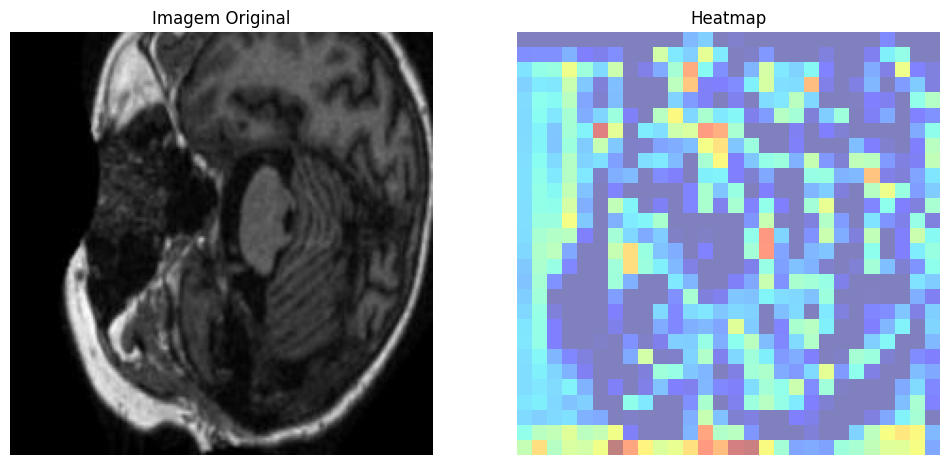

In [9]:
mapa_de_calor('./predict/Mild Dementia.jpg')

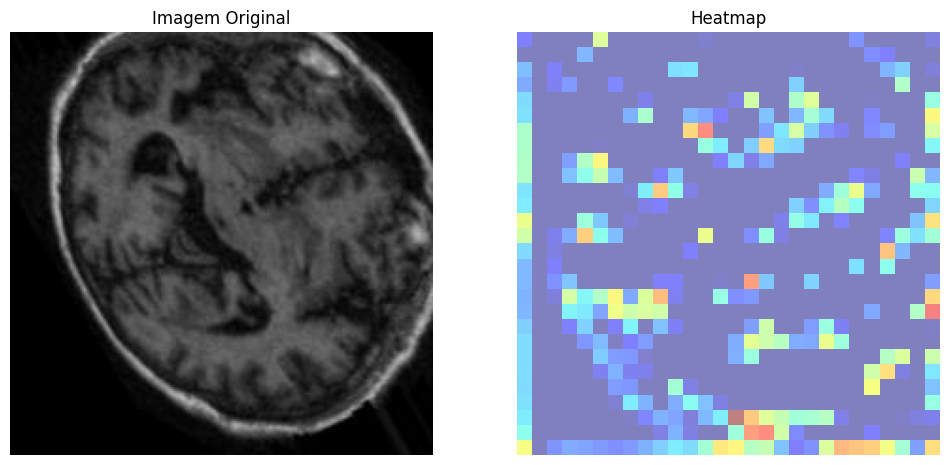

In [10]:
mapa_de_calor('./predict/Moderate Dementia.jpg')

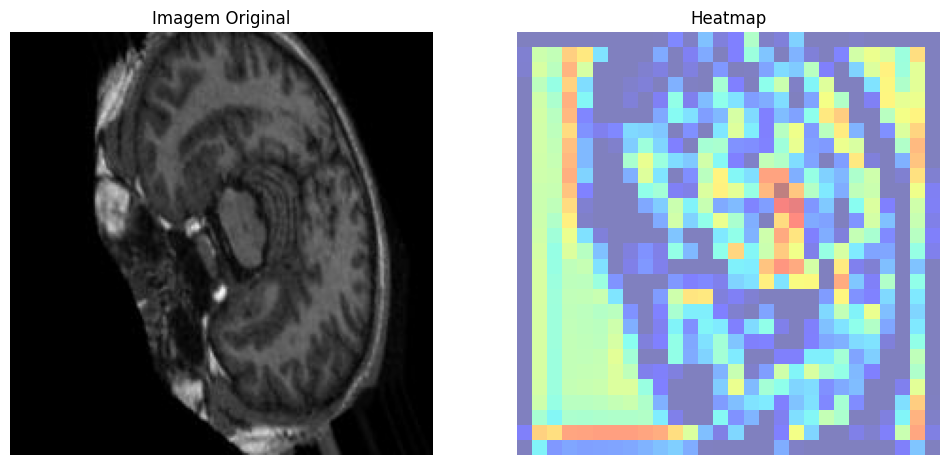

In [12]:
mapa_de_calor('./predict/Non Demented.jpg')

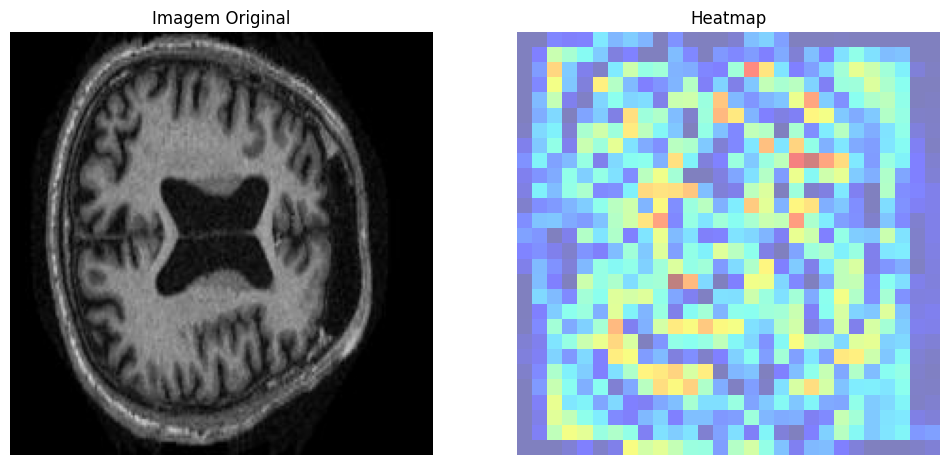

In [13]:
mapa_de_calor('./predict/Very mild Dementia.jpg')